<a href="https://colab.research.google.com/github/harrisariefkamis/HACKATHON-Retail-Crisis-Recovery-Visualization-Challenge/blob/main/solusi_retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## SCRIPT SOLUSI-RETAIL-FINAL

✅ 4 Rising Star ditemukan:


,Kode Produk,Nama Produk,Growth %,Total Penjualan
1,MGR1L,Minyak Goreng Refill 1L,712.07,25515000
0,BRS5KG,Beras Premium 5kg,700.00,39838500
2,SCC15L,Sabun Cuci Cair 1.5L,551.90,93800000
3,WJANEM,Wajan Enamel Anti Lengket,536.84,43120000


📊 'Rising Star — DQFresh Mart' → https://docs.google.com/spreadsheets/d/1OLiHlxRVgVQ9d7CTZqwCzYhoiSwBl7lFWnKjNvbi5TY
Total transaksi diproses: 9,403
Frequent itemsets ditemukan: 748
✅ 34 aturan Potential Packaging ditemukan:


,Jika Membeli,Maka Membeli,Jumlah Invoice,Support,Confidence,Lift
0,Beras Premium 5kg,Minyak Goreng Refill 1L,100,0.010635,0.255754,2.301301
1,Minyak Goreng Refill 1L,Beras Premium 5kg,100,0.010635,0.095694,2.301301
2,"Kaos Kaki (3 Pasang), Sabun Cuci Cair 1.5L",Minyak Goreng Refill 1L,185,0.019675,0.251018,2.258678
3,Minyak Goreng Refill 1L,"Kaos Kaki (3 Pasang), Sabun Cuci Cair 1.5L",185,0.019675,0.177033,2.258678
4,"Kaos Kaki (3 Pasang), Minyak Goreng Refill 1L",Sabun Cuci Cair 1.5L,185,0.019675,0.214368,2.227300
5,Sabun Cuci Cair 1.5L,"Kaos Kaki (3 Pasang), Minyak Goreng Refill 1L",185,0.019675,0.204420,2.227300
6,Masker Medis (1 Box),"Kaos Kaki (3 Pasang), Snack Keripik Kentang",96,0.010210,0.180113,2.130313
7,"Kaos Kaki (3 Pasang), Snack Keripik Kentang",Masker Medis (1 Box),96,0.010210,0.120755,2.130313
8,"Garam Dapur (3 Pack), Sabun Cuci Tangan Reffil",Cairan Pembersih Lantai 2L,99,0.010529,0.150456,2.127424
9,Cairan Pembersih Lantai 2L,"Garam Dapur (3 Pack), Sabun Cuci Tangan Reffil",99,0.010529,0.148872,2.127424


📊 'Potential Packaging — DQFresh Mart' → https://docs.google.com/spreadsheets/d/1lPSJ2v3EdbUiUADyQf1t8MZ4L_SVXxshPSWnEaJmkW4


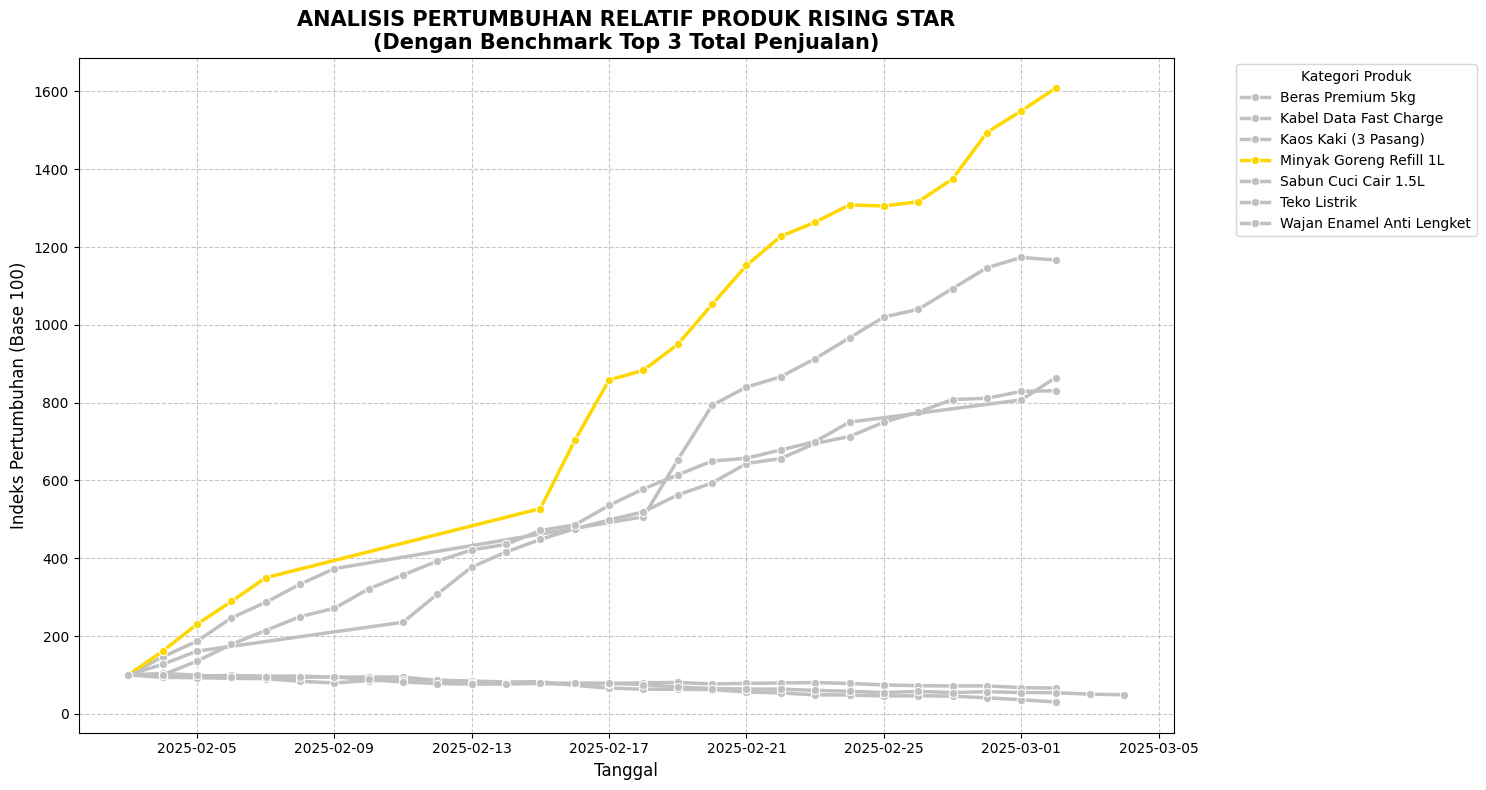

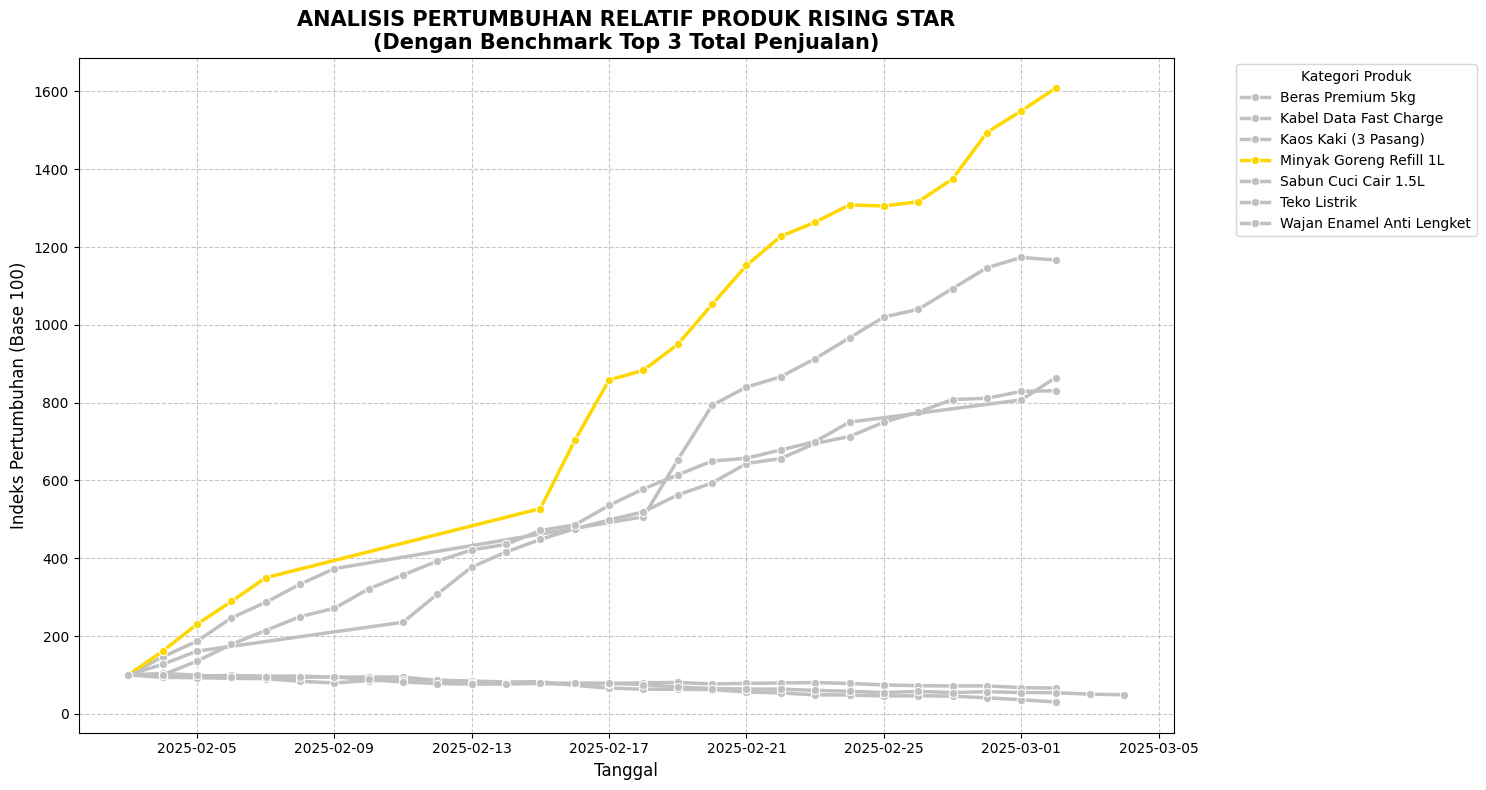

In [117]:
'''
solusi-retail.py
Dataset:
  nomor_struk   STRING
  tgl_transaksi DATETIME
  kode_produk   STRING
  nama_produk   STRING
  jumlah_terjual INTEGER
  harga         INTEGER
  total_nilai   INTEGER
'''

# INSTALL
!pip install gspread mlxtend --quiet

# IMPORT LIBRARY PYTHON
import pandas as pd
import matplotlib.pyplot as plt
import gspread
from google.colab import auth
from google.auth import default
from mlxtend.frequent_patterns import apriori, association_rules

# GOOGLE AUTH
auth.authenticate_user()
creds, _ = default()
gc = gspread.Client(auth=creds)

# Export ke Google Sheets
def export_sheet(gc, title, dataframe):

    data = dataframe.copy().astype(str)
    try:
        sh = gc.open(title)
        ws = sh.get_worksheet(0)
        ws.clear()
    except gspread.exceptions.SpreadsheetNotFound:
        sh = gc.create(title)
        ws = sh.get_worksheet(0)
    ws.update(
        range_name='A1',
        values=[data.columns.tolist()] + data.values.tolist()
    )
    print(f"📊 '{title}' → {sh.url}")


# LOAD DATA
df = pd.read_csv('/content/data_penjualan.csv', sep=';')
df['tgl_transaksi'] = pd.to_datetime(df['tgl_transaksi'], dayfirst=True)
df = df.sort_values(['nama_produk', 'tgl_transaksi'])

# RISING STAR
# A. Agregasi harian
daily = (
    df.groupby(['kode_produk', 'nama_produk', 'tgl_transaksi'])['total_nilai']
    .sum()
    .reset_index()
    .sort_values(['nama_produk', 'tgl_transaksi'])
)

# B. Moving Average 3 hari
daily['MA'] = (
    daily.groupby('nama_produk')['total_nilai']
    .transform(lambda x: x.rolling(window=3, min_periods=3).mean())
)
daily.dropna(subset=['MA'], inplace=True)

# C. Identifikasi Tren Naik (Rising Trend)
daily['is_rising'] = daily.groupby('nama_produk')['MA'].diff() > 0

# D. Session ID unik per blok tren
daily['trend_session_id'] = (
    daily['is_rising'] != daily.groupby('nama_produk')['is_rising'].shift()
).cumsum()

# E. Hitung consecutive days
daily['consecutive_days'] = daily.groupby(
    ['nama_produk', 'trend_session_id']
)['tgl_transaksi'].transform('count')
daily.loc[~daily['is_rising'], 'consecutive_days'] = 0

# F. Filter sesi ≥12 hari
valid_sessions = (
    daily[daily['consecutive_days'] >= 12]
    [['kode_produk', 'nama_produk', 'trend_session_id']]
    .drop_duplicates()
)

# G. Hitung Growth %
results = []
for _, row in valid_sessions.iterrows():
    sesi = daily[
        (daily['nama_produk']      == row['nama_produk']) &
        (daily['trend_session_id'] == row['trend_session_id'])
    ]
    ma_awal  = sesi['MA'].iloc[0]
    ma_akhir = sesi['MA'].iloc[-1]
    growth   = ((ma_akhir / ma_awal) - 1) * 100 if ma_awal != 0 else 0
    results.append({
        'Kode Produk'    : row['kode_produk'],
        'Nama Produk'    : row['nama_produk'],
        'Growth %'       : round(growth, 2),
        'Total Penjualan': int(sesi['total_nilai'].sum()),
    })

df_final = pd.DataFrame(results).sort_values('Growth %', ascending=False)

# H. longest_trends
longest_trends = (
    daily[daily['is_rising']]
    .groupby(['kode_produk', 'nama_produk', 'trend_session_id'])['consecutive_days']
    .max()
    .reset_index()
    .sort_values('consecutive_days', ascending=False)
    .drop_duplicates('nama_produk')
    .reset_index(drop=True)
)

# I. Tampilkan hasil
if df_final.empty:
    print("⚠️  Tidak ada Rising Star ≥ 12 hari. Top 5 tren terlama:")
    display(longest_trends.head(5))
else:
    print(f"✅ {len(df_final)} Rising Star ditemukan:")
    display(df_final)

export_sheet(gc, 'Rising Star — DQFresh Mart', df_final)


# POTENTIAL PACKAGING — ASSOCIATION RULES

# A. Basket matrix — 1 baris per nomor_struk, kolom = nama_produk
basket_sets = (
    df.groupby(['nomor_struk', 'nama_produk'])['jumlah_terjual']
    .sum()
    .unstack()
    .fillna(0)
    .map(lambda x: x > 0)
)

total_transaksi = len(basket_sets)
print(f"Total transaksi diproses: {total_transaksi:,}")

# B. Frequent Itemsets (min_support = 1%)
frequent_itemsets = apriori(
    basket_sets,
    min_support=0.01,
    use_colnames=True
)
print(f"Frequent itemsets ditemukan: {len(frequent_itemsets):,}")

# C. Association Rules (metric=lift, min_threshold=1)
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1,
    num_itemsets=total_transaksi
)

rising_star_list = longest_trends['nama_produk'].unique().tolist()

def filter_rising_star(row):
    in_rising = (
        any(item in rising_star_list for item in row['antecedents']) or
        any(item in rising_star_list for item in row['consequents'])
    )
    return in_rising and row['lift'] >= 2

potential_packaging = rules[rules.apply(filter_rising_star, axis=1)].copy()

# E. Hitung Jumlah Invoice = support × total transaksi
potential_packaging['Jumlah Invoice'] = (
    potential_packaging['support'] * total_transaksi
).round(0).astype(int)

# F. Konversi frozenset → string (Jika Membeli / Maka Membeli)
potential_packaging['Jika Membeli']  = potential_packaging['antecedents']\
    .apply(lambda x: ', '.join(sorted(list(x))))
potential_packaging['Maka Membeli']  = potential_packaging['consequents']\
    .apply(lambda x: ', '.join(sorted(list(x))))

# G. Urutkan: Lift → Support → Confidence (descending)
potential_packaging = potential_packaging.sort_values(
    by=['lift', 'support', 'confidence'],
    ascending=[False, False, False]
).reset_index(drop=True)

# H. Pilih & urutkan kolom sesuai output
output_cols = [
    'Jika Membeli',
    'Maka Membeli',
    'Jumlah Invoice',
    'support',
    'confidence',
    'lift',
]
potential_packaging_final = potential_packaging[output_cols].copy()

# Rename agar konsisten
potential_packaging_final.columns = [
    'Jika Membeli',
    'Maka Membeli',
    'Jumlah Invoice',
    'Support',
    'Confidence',
    'Lift',
]

# I. Tampilkan hasil
if potential_packaging_final.empty:
    print("⚠️  Tidak ada kombinasi Potential Packaging yang memenuhi kriteria.")
else:
    print(f"✅ {len(potential_packaging_final)} aturan Potential Packaging ditemukan:")
    display(potential_packaging_final.head(20))

# J. Export ke Google Sheets
export_sheet(gc, 'Potential Packaging — DQFresh Mart', potential_packaging_final)


# VISUALISASI RISSING STAR
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
highlight_product = 'Minyak Goreng Refill 1L'

top_3_overall = df.groupby('nama_produk')['total_nilai'].sum().nlargest(3).index.tolist()
rising_stars_list = df_final['Nama Produk'].tolist()
target_products = list(set(rising_stars_list + top_3_overall))

def get_custom_palette(products, highlight):
    palette_dict = {}
    for prod in products:
        if prod == highlight:
            palette_dict[prod] = 'gold'
        else:
            palette_dict[prod] = 'silver'
    return palette_dict

custom_palette = get_custom_palette(target_products, highlight_product)

data_idx = daily[daily['nama_produk'].isin(target_products)].copy()
def apply_base_100(group):
    first_ma = group['MA'].iloc[0]
    group['Growth_Index'] = (group['MA'] / first_ma) * 100
    return group

data_idx = data_idx.groupby('nama_produk', group_keys=False).apply(apply_base_100)

plt.figure(figsize=(15, 8))
sns.lineplot(data=data_idx, x='tgl_transaksi', y='Growth_Index', hue='nama_produk',
             palette=custom_palette, marker='o', linewidth=2.5)

plt.title('ANALISIS PERTUMBUHAN RELATIF PRODUK RISING STAR\n(Dengan Benchmark Top 3 Total Penjualan)', fontsize=15, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Indeks Pertumbuhan (Base 100)', fontsize=12)
plt.legend(title='Kategori Produk', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('pertumbuhan_relatif.png', dpi=300)
plt.show()


# Visualisasi Pertumbuhan dengan Nilai Aktual
highlight_product = 'Minyak Goreng Refill 1L'

top_3_overall = df.groupby('nama_produk')['total_nilai'].sum().nlargest(3).index.tolist()
rising_stars_list = df_final['Nama Produk'].tolist()
target_products = list(set(rising_stars_list + top_3_overall))

def get_custom_palette(products, highlight):
    palette_dict = {}
    for prod in products:
        if prod == highlight:
            palette_dict[prod] = 'gold'
        else:
            palette_dict[prod] = 'silver'
    return palette_dict

custom_palette = get_custom_palette(target_products, highlight_product)

data_idx = daily[daily['nama_produk'].isin(target_products)].copy()
def apply_base_100(group):
    first_ma = group['MA'].iloc[0]
    group['Growth_Index'] = (group['MA'] / first_ma) * 100
    return group

data_idx = data_idx.groupby('nama_produk', group_keys=False).apply(apply_base_100)

plt.figure(figsize=(15, 8))
sns.lineplot(data=data_idx, x='tgl_transaksi', y='Growth_Index', hue='nama_produk',
             palette=custom_palette, marker='o', linewidth=2.5)

plt.title('ANALISIS PERTUMBUHAN RELATIF PRODUK RISING STAR\n(Dengan Benchmark Top 3 Total Penjualan)', fontsize=15, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Indeks Pertumbuhan (Base 100)', fontsize=12)
plt.legend(title='Kategori Produk', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('pertumbuhan_relatif.png', dpi=300)
plt.show()

## VISUALISASI DASBOARD RISSING STAR

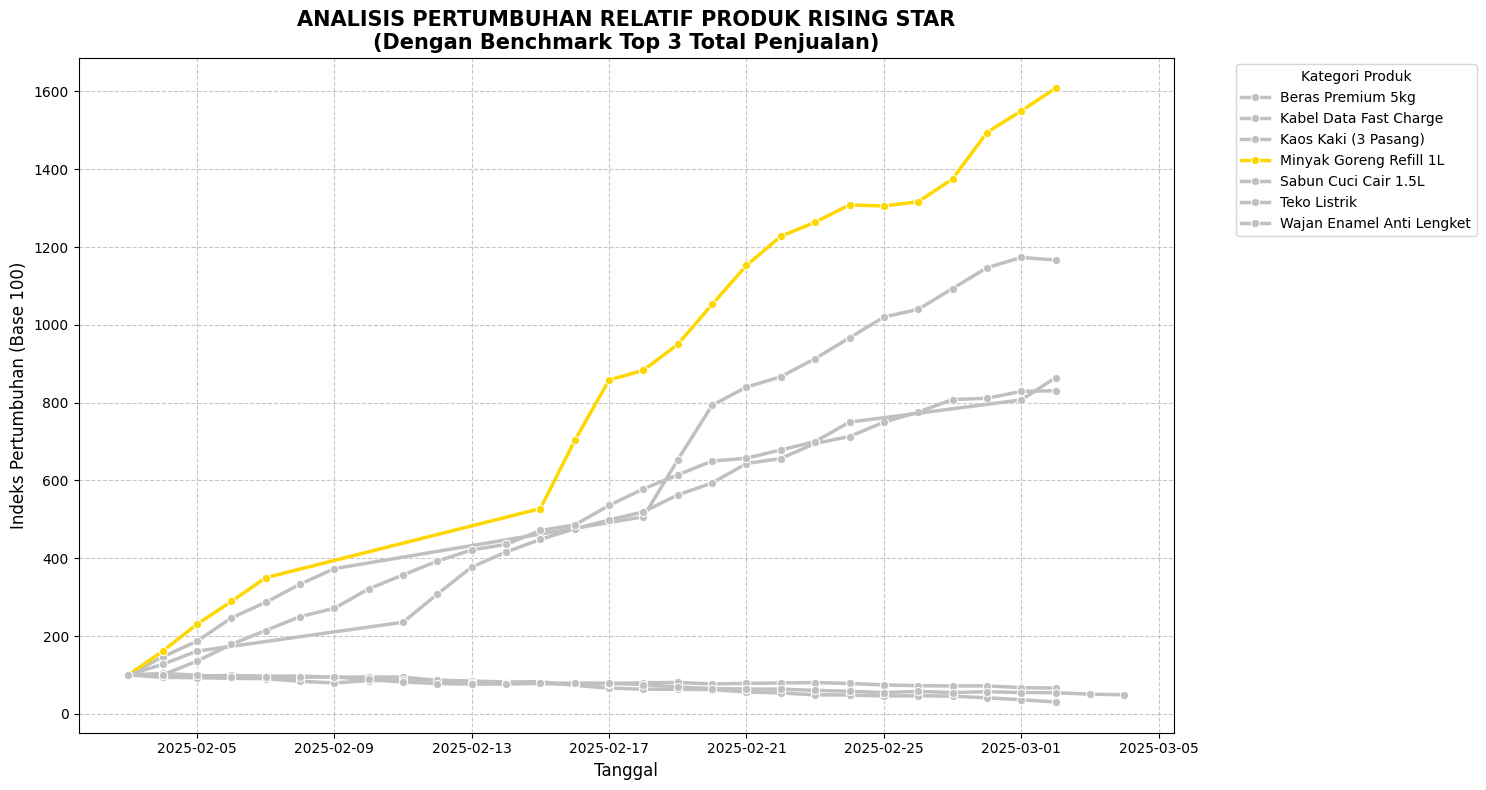

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

highlight_product = 'Minyak Goreng Refill 1L'

top_3_overall = df.groupby('nama_produk')['total_nilai'].sum().nlargest(3).index.tolist()
rising_stars_list = df_final['Nama Produk'].tolist()
target_products = list(set(rising_stars_list + top_3_overall))

def get_custom_palette(products, highlight):
    palette_dict = {}
    for prod in products:
        if prod == highlight:
            palette_dict[prod] = 'gold'
        else:
            palette_dict[prod] = 'silver'
    return palette_dict

custom_palette = get_custom_palette(target_products, highlight_product)

data_idx = daily[daily['nama_produk'].isin(target_products)].copy()
def apply_base_100(group):
    first_ma = group['MA'].iloc[0]
    group['Growth_Index'] = (group['MA'] / first_ma) * 100
    return group

data_idx = data_idx.groupby('nama_produk', group_keys=False).apply(apply_base_100)

plt.figure(figsize=(15, 8))
sns.lineplot(data=data_idx, x='tgl_transaksi', y='Growth_Index', hue='nama_produk',
             palette=custom_palette, marker='o', linewidth=2.5)

plt.title('ANALISIS PERTUMBUHAN RELATIF PRODUK RISING STAR\n(Dengan Benchmark Top 3 Total Penjualan)', fontsize=15, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Indeks Pertumbuhan (Base 100)', fontsize=12)
plt.legend(title='Kategori Produk', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()


plt.savefig('pertumbuhan_relatif.png', dpi=300)
plt.show()

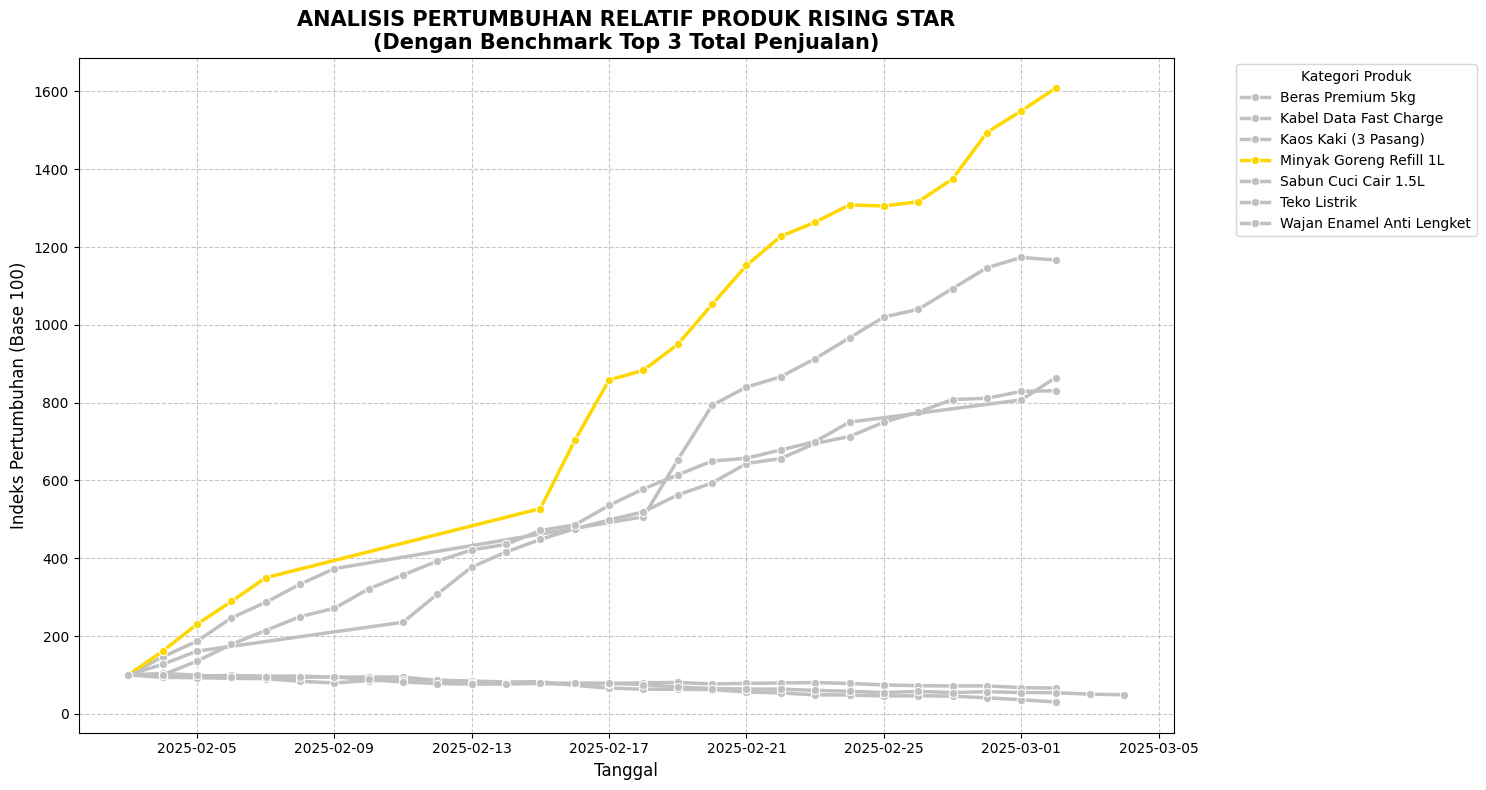

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

highlight_product = 'Minyak Goreng Refill 1L'

top_3_overall = df.groupby('nama_produk')['total_nilai'].sum().nlargest(3).index.tolist()
rising_stars_list = df_final['Nama Produk'].tolist()
target_products = list(set(rising_stars_list + top_3_overall))

def get_custom_palette(products, highlight):
    palette_dict = {}
    for prod in products:
        if prod == highlight:
            palette_dict[prod] = 'gold'
        else:
            palette_dict[prod] = 'silver'
    return palette_dict

custom_palette = get_custom_palette(target_products, highlight_product)

data_idx = daily[daily['nama_produk'].isin(target_products)].copy()
def apply_base_100(group):
    first_ma = group['MA'].iloc[0]
    group['Growth_Index'] = (group['MA'] / first_ma) * 100
    return group

data_idx = data_idx.groupby('nama_produk', group_keys=False).apply(apply_base_100)

plt.figure(figsize=(15, 8))
sns.lineplot(data=data_idx, x='tgl_transaksi', y='Growth_Index', hue='nama_produk',
             palette=custom_palette, marker='o', linewidth=2.5)

plt.title('ANALISIS PERTUMBUHAN RELATIF PRODUK RISING STAR\n(Dengan Benchmark Top 3 Total Penjualan)', fontsize=15, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Indeks Pertumbuhan (Base 100)', fontsize=12)
plt.legend(title='Kategori Produk', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()


plt.savefig('pertumbuhan_relatif.png', dpi=300)
plt.show()